In [2]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np



In [5]:

print(f"PyTorch version: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.10.0+cpu
Using device: cpu


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("satyanshgaur1/rain-prediction-training-dataset")

print("Path to dataset files:", path)

df = pd.read_parquet(path + "/train.parquet")
print("Shape:", df.shape)
df.head()

Path to dataset files: C:\Users\Justin\.cache\kagglehub\datasets\satyanshgaur1\rain-prediction-training-dataset\versions\1
Shape: (420000, 36)


,timestamp,received_snr_db,carrier_frequency_ghz,elevation_angle_deg,slant_range_km,fspl_db,gaseous_attenuation_db,excess_attenuation_db,effective_path_length_km,specific_attenuation_db_per_km,...,snr_roll_mean_5min,snr_roll_std_5min,snr_roll_max_5min,snr_roll_min_5min,snr_roll_mean_30min,snr_roll_std_30min,attenuation_roll_mean,attenuation_roll_std,attenuation_delta,snr_delta
0,2026-07-01 00:00:00+00:00,13.547272,10.0,-4.034088,42443.268793,205.006176,2.249753,2.243240,41.541219,0.054000,...,13.547272,0.000000,13.547272,13.547272,13.547272,0.000000,2.243240,0.000000,0.000000,0.000000
1,2026-07-01 00:01:00+00:00,13.881465,10.0,-4.052777,42445.258502,205.006584,2.249753,1.908641,41.541219,0.045946,...,13.714368,0.236310,13.881465,13.547272,13.714368,0.236310,2.075941,0.236598,-0.334600,0.334192
2,2026-07-01 00:02:00+00:00,12.847182,10.0,-4.071395,42447.240791,205.006989,2.249753,2.942518,41.541219,0.070834,...,13.425306,0.527818,13.881465,12.847182,13.425306,0.527818,2.364800,0.527549,1.033877,-1.034282
3,2026-07-01 00:03:00+00:00,7.825947,10.0,-4.089941,42449.215620,205.007393,2.249753,7.963348,41.541219,0.191698,...,12.025467,2.832655,13.881465,7.825947,12.025467,2.832655,3.764437,2.832221,5.020831,-5.021235
4,2026-07-01 00:04:00+00:00,10.745718,10.0,-4.108415,42451.182953,205.007796,2.249753,5.043175,41.541219,0.121402,...,11.769517,2.519028,13.881465,7.825947,11.769517,2.519028,4.020185,2.518559,-2.920173,2.919771


In [7]:
columns = df.columns.tolist()
columns

['timestamp',
 'received_snr_db',
 'carrier_frequency_ghz',
 'elevation_angle_deg',
 'slant_range_km',
 'fspl_db',
 'gaseous_attenuation_db',
 'excess_attenuation_db',
 'effective_path_length_km',
 'specific_attenuation_db_per_km',
 'rain_height_km',
 'frequency_ghz',
 'itu_k',
 'itu_alpha',
 'station',
 'climate',
 'simulation_id',
 'rain_rate_mm_per_hr',
 'rain_event',
 'season_sin',
 'season_cos',
 'gs_latitude',
 'gs_humidity',
 'gs_wv',
 'itu_R001',
 'itu_P_rain',
 'snr_roll_mean_5min',
 'snr_roll_std_5min',
 'snr_roll_max_5min',
 'snr_roll_min_5min',
 'snr_roll_mean_30min',
 'snr_roll_std_30min',
 'attenuation_roll_mean',
 'attenuation_roll_std',
 'attenuation_delta',
 'snr_delta']

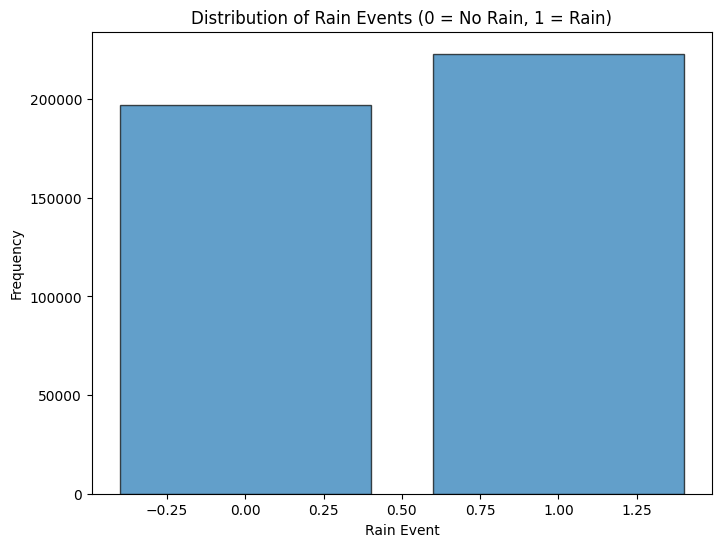

In [23]:
plt.figure(figsize=(8, 6))
plt.bar(df['rain_event'].value_counts().index, df['rain_event'].value_counts().values, edgecolor='black', alpha=0.7)
plt.xlabel('Rain Event')
plt.ylabel('Frequency')
plt.title('Distribution of Rain Events (0 = No Rain, 1 = Rain)')

plt.show()

In [35]:
first_day = df['timestamp'].min()
last_day = df['timestamp'].max()

print(f"First day / hr in dataset: {first_day}")
print(f"Last day / hr in dataset: {last_day}")
print(f"Total days in dataset: {(last_day - first_day).days + 1}")
print(f"Total hours in dataset: {(last_day - first_day).total_seconds() / 3600 + 1}")
print(f"Total minutes in dataset: {(last_day - first_day).total_seconds() / 60 + 1}")
print(f"Total rows in dataset: {df.shape[0]}")

First day / hr in dataset: 2026-01-01 00:00:00+00:00
Last day / hr in dataset: 2026-11-08 06:59:00+00:00
Total days in dataset: 312
Total hours in dataset: 7471.983333333334
Total minutes in dataset: 448260.0
Total rows in dataset: 420000


In [33]:
rows = df.shape[0]
print(f"Total rows in dataset: {rows}")

Total rows in dataset: 420000
